In [213]:
!pip install mediapipe opencv-python scikit-learn matplotlib seaborn numpy pandas


In [256]:
import cv2
import mediapipe as mp
import numpy as np
import os


In [258]:
class PoseExtractor:
    def __init__(self):
        self.mp_pose = mp.solutions.pose
        self.pose = self.mp_pose.Pose()

    def extract_pose_from_video(self, video_path):
        cap = cv2.VideoCapture(video_path)
        all_landmarks = []
        
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = self.pose.process(frame_rgb)
            
            if results.pose_landmarks:
                landmarks = []
                for lm in results.pose_landmarks.landmark:
                    landmarks.extend([lm.x, lm.y, lm.z])
                all_landmarks.append(landmarks)
        
        cap.release()
        return np.array(all_landmarks)

    def save_pose(self, video_path, save_path):
        poses = self.extract_pose_from_video(video_path)
        np.save(save_path, poses)


In [260]:
pose_extractor = PoseExtractor()

fight_videos = os.listdir(r'C:\Users\BALA KARTHIK KOSURI\Documents\Fight_Pose_Project\Data\Raw\fight')
non_fight_videos = os.listdir(r'C:\Users\BALA KARTHIK KOSURI\Documents\Fight_Pose_Project\Data\Raw\noFight')

# Fight videos
for video in fight_videos:
    video_path = r'C:\Users\BALA KARTHIK KOSURI\Documents\Fight_Pose_Project\Data\Raw\fight{video}'
    save_path = r'C:\Users\BALA KARTHIK KOSURI\Documents\Fight_Pose_Project\Poses\fight{video}.npy'
    pose_extractor.save_pose(video_path, save_path)

# Non-Fight videos
for video in non_fight_videos:
    video_path = r'C:\Users\BALA KARTHIK KOSURI\Documents\Fight_Pose_Project\Data\Raw\noFight{video}'
    save_path = r'C:\Users\BALA KARTHIK KOSURI\Documents\Fight_Pose_Project\Poses\noFight{video}.npy'
    pose_extractor.save_pose(video_path, save_path)


# FEATURE EXTRACTION

In [263]:
import numpy as np
import os
import pandas as pd


In [265]:
class FeatureEngineer:
    def __init__(self):
        self.nose_idx = 0
        self.left_hand_idx = 15
        self.right_hand_idx = 16

    def extract_features(self, pose_array):
        if len(pose_array) < 2:
            return None
        
        pose_array = np.array(pose_array)
        features = []
        
        for idx in [self.nose_idx, self.left_hand_idx, self.right_hand_idx]:
            x = pose_array[:, idx*3]
            y = pose_array[:, idx*3+1]
            z = pose_array[:, idx*3+2]

            velocity = np.sqrt(np.diff(x)**2 + np.diff(y)**2 + np.diff(z)**2)
            acceleration = np.diff(velocity)

            features.extend([
                np.mean(velocity),
                np.max(velocity),
                np.var(velocity),
                np.mean(acceleration),
                np.max(acceleration),
                np.var(acceleration)
            ])
        
        return np.array(features)


In [267]:
import os
os.listdir("Poses")

['fight', 'fight{video}.npy', 'noFight', 'noFight{video}.npy']

# FEATURE EXTRACTION

In [270]:
import os
import numpy as np

engineer = FeatureEngineer()

X = []
y = []

# Fight Poses
fight_pose_folder = r'C:\Users\BALA KARTHIK KOSURI\Documents\Fight_Pose_Project\Poses\fight'
fight_pose_files = os.listdir(fight_pose_folder)

for file in fight_pose_files:
    if file.endswith('.npy'):
        npfile = os.path.join(fight_pose_folder, file)
        pose = np.load(npfile, allow_pickle=True)
        features = engineer.extract_features(pose)
        if features is not None:
            X.append(features)
            y.append(1)  # Fight = 1

# Non-Fight Poses
non_fight_pose_folder = r'C:\Users\BALA KARTHIK KOSURI\Documents\Fight_Pose_Project\Poses\noFight'
non_fight_pose_files = os.listdir(non_fight_pose_folder)

for file in non_fight_pose_files:
    if file.endswith('.npy'):
        npfile = os.path.join(non_fight_pose_folder, file)
        pose = np.load(npfile, allow_pickle=True)
        features = engineer.extract_features(pose)
        if features is not None:
            X.append(features)
            y.append(0)  # Non-fight = 0

X = np.array(X)
y = np.array(y)

print(X.shape, y.shape)


(300, 18) (300,)


In [272]:
print(f"Found {len(fight_pose_files)} fight pose files")
print(f"Found {len(non_fight_pose_files)} non-fight pose files")


Found 300 fight pose files
Found 300 non-fight pose files


In [274]:
print("Processing:", npfile)


Processing: C:\Users\BALA KARTHIK KOSURI\Documents\Fight_Pose_Project\Poses\noFight\nofi150.npy


In [276]:
import os

fight_pose_folder = r'C:\Users\BALA KARTHIK KOSURI\Documents\Fight_Pose_Project\Poses\fight'
files = os.listdir(fight_pose_folder)

print(files)


['fi001.mp4', 'fi001.npy', 'fi002.mp4', 'fi002.npy', 'fi003.mp4', 'fi003.npy', 'fi004.mp4', 'fi004.npy', 'fi005.mp4', 'fi005.npy', 'fi006.mp4', 'fi006.npy', 'fi007.mp4', 'fi007.npy', 'fi008.mp4', 'fi008.npy', 'fi009.mp4', 'fi009.npy', 'fi010.mp4', 'fi010.npy', 'fi011.mp4', 'fi011.npy', 'fi012.mp4', 'fi012.npy', 'fi013.mp4', 'fi013.npy', 'fi014.mp4', 'fi014.npy', 'fi015.mp4', 'fi015.npy', 'fi016.mp4', 'fi016.npy', 'fi017.mp4', 'fi017.npy', 'fi018.mp4', 'fi018.npy', 'fi019.mp4', 'fi019.npy', 'fi020.mp4', 'fi020.npy', 'fi021.mp4', 'fi021.npy', 'fi022.mp4', 'fi022.npy', 'fi023.mp4', 'fi023.npy', 'fi024.mp4', 'fi024.npy', 'fi025.mp4', 'fi025.npy', 'fi026.mp4', 'fi026.npy', 'fi027.mp4', 'fi027.npy', 'fi028.mp4', 'fi028.npy', 'fi029.mp4', 'fi029.npy', 'fi030.mp4', 'fi030.npy', 'fi031.mp4', 'fi031.npy', 'fi032.mp4', 'fi032.npy', 'fi033.mp4', 'fi033.npy', 'fi034.mp4', 'fi034.npy', 'fi035.mp4', 'fi035.npy', 'fi036.mp4', 'fi036.npy', 'fi037.mp4', 'fi037.npy', 'fi038.mp4', 'fi038.npy', 'fi039.mp4'

In [278]:
import cv2
import mediapipe as mp
import os
import numpy as np
from tqdm import tqdm

# Initialize MediaPipe pose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=False, min_detection_confidence=0.5, min_tracking_confidence=0.5)

# Function to extract pose keypoints from one frame
def extract_keypoints(results):
    if results.pose_landmarks:
        keypoints = []
        for lm in results.pose_landmarks.landmark:
            keypoints.extend([lm.x, lm.y, lm.z, lm.visibility])
        return np.array(keypoints)
    else:
        return np.zeros(33 * 4)  # 33 landmarks, each with (x, y, z, visibility)

# Input and Output folders
input_folder_fight = r'C:\Users\BALA KARTHIK KOSURI\Documents\Fight_Pose_Project\Data\Raw\fight'
input_folder_nonfight = r'C:\Users\BALA KARTHIK KOSURI\Documents\Fight_Pose_Project\Data\Raw\noFight'

output_folder_fight = r'C:\Users\BALA KARTHIK KOSURI\Documents\Fight_Pose_Project\Poses\fight'
output_folder_nonfight = r'C:\Users\BALA KARTHIK KOSURI\Documents\Fight_Pose_Project\Poses\noFight'

os.makedirs(output_folder_fight, exist_ok=True)
os.makedirs(output_folder_nonfight, exist_ok=True)

# Function to process videos
def process_videos(input_folder, output_folder):
    video_files = os.listdir(input_folder)
    for video_name in tqdm(video_files):
        if video_name.endswith('.mp4'):
            cap = cv2.VideoCapture(os.path.join(input_folder, video_name))
            all_keypoints = []
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break
                # Resize and process
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                results = pose.process(frame)
                keypoints = extract_keypoints(results)
                all_keypoints.append(keypoints)
            cap.release()
            
            all_keypoints = np.array(all_keypoints)
            # Save
            np.save(os.path.join(output_folder, video_name.replace('.mp4', '.npy')), all_keypoints)

# Process fight and non-fight videos
process_videos(input_folder_fight, output_folder_fight)
process_videos(input_folder_nonfight, output_folder_nonfight)

print("Pose extraction completed!")


100%|██████████| 150/150 [05:04<00:00,  2.03s/it]

Pose extraction completed!


In [280]:
import numpy as np

class FeatureEngineer:
    def __init__(self):
        pass

    def extract_features(self, keypoints_sequence):
        # keypoints_sequence: (frames, 132) shape

        if keypoints_sequence.shape[0] < 1:
            return None

        # Use simple statistics: mean and std over frames
        mean_features = np.mean(keypoints_sequence, axis=0)
        std_features = np.std(keypoints_sequence, axis=0)

        # Concatenate mean and std to form final feature vector
        features = np.concatenate([mean_features, std_features])

        return features


In [282]:
import os

engineer = FeatureEngineer()

X = []
y = []

# Fight Poses
fight_pose_folder = r'C:\Users\BALA KARTHIK KOSURI\Documents\Fight_Pose_Project\Poses\fight'
fight_pose_files = os.listdir(fight_pose_folder)

for file in fight_pose_files:
    if file.endswith('.npy'):
        pose = np.load(os.path.join(fight_pose_folder, file))
        features = engineer.extract_features(pose)
        if features is not None:
            X.append(features)
            y.append(1)  # Fight = 1

# Non-Fight Poses
nonfight_pose_folder = r'C:\Users\BALA KARTHIK KOSURI\Documents\Fight_Pose_Project\Poses\noFight'
non_fight_pose_files = os.listdir(nonfight_pose_folder)

for file in non_fight_pose_files:
    if file.endswith('.npy'):
        pose = np.load(os.path.join(nonfight_pose_folder, file))
        features = engineer.extract_features(pose)
        if features is not None:
            X.append(features)
            y.append(0)  # Non-fight = 0

X = np.array(X)
y = np.array(y)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (300, 264)
Shape of y: (300,)


Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.50      0.58        30
           1       0.61      0.77      0.68        30

    accuracy                           0.63        60
   macro avg       0.64      0.63      0.63        60
weighted avg       0.64      0.63      0.63        60

Confusion Matrix:


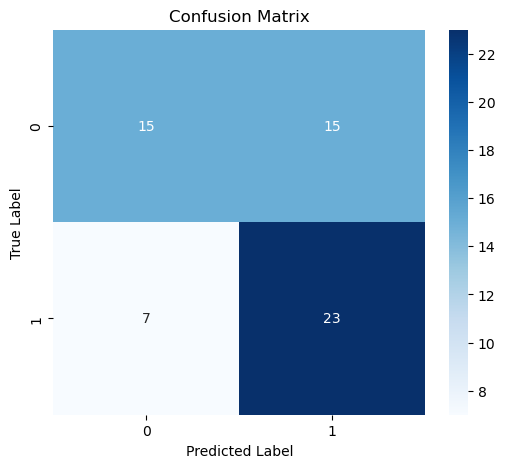

Accuracy: 0.6333


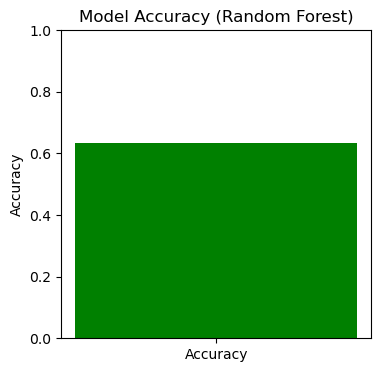

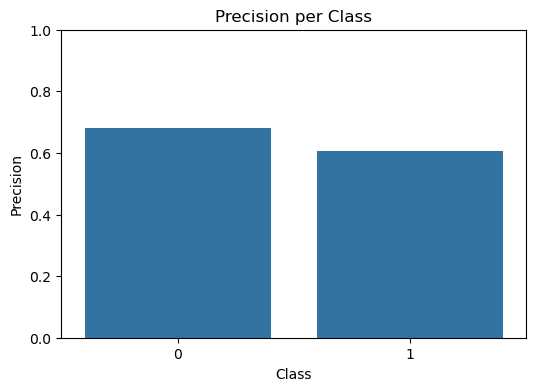

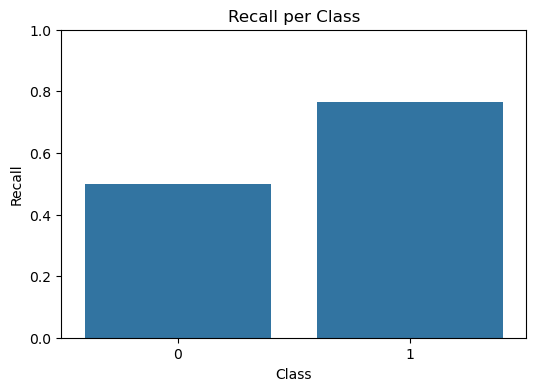

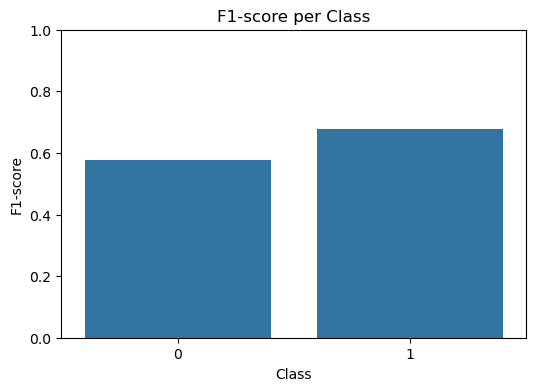

In [284]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("Classification Report:")
report = classification_report(y_test, y_pred, output_dict=True)
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# ---- Graphs ----

# 1. Accuracy Bar Chart
plt.figure(figsize=(4, 4))
plt.bar(['Accuracy'], [accuracy], color='green')
plt.ylim(0, 1)
plt.title('Model Accuracy (Random Forest)')
plt.ylabel('Accuracy')
plt.show()

# 2. Classification Report (Precision, Recall, F1-score)
metrics = ['precision', 'recall', 'f1-score']
classes = list(report.keys())[:-3]  # Exclude avg/total

for metric in metrics:
    values = [report[cls][metric] for cls in classes]
    plt.figure(figsize=(6, 4))
    sns.barplot(x=classes, y=values)
    plt.ylim(0, 1)
    plt.title(f'{metric.capitalize()} per Class')
    plt.ylabel(metric.capitalize())
    plt.xlabel('Class')
    plt.show()


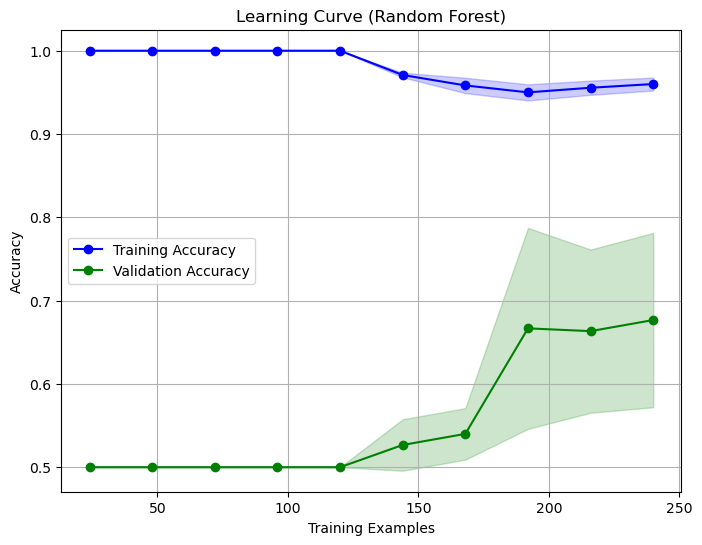

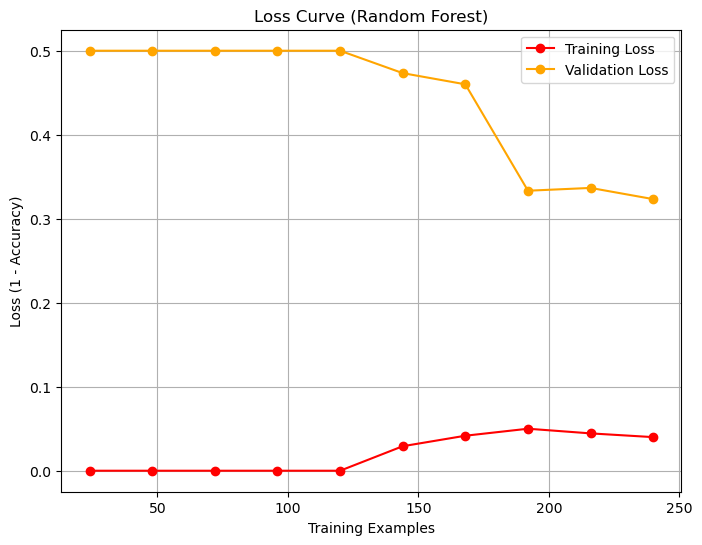

In [286]:
from sklearn.model_selection import learning_curve
import numpy as np

# Calculate learning curve
train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

# Calculate mean and std for training/test scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot the learning curve (Accuracy graph)
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Accuracy")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Validation Accuracy")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color="green")
plt.title('Learning Curve (Random Forest)')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.legend(loc="best")
plt.grid(True)
plt.show()

# Now simulate 'Loss' as (1 - Accuracy)
train_loss = 1 - train_mean
test_loss = 1 - test_mean

# Plot the loss curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_loss, 'o-', color="red", label="Training Loss")
plt.plot(train_sizes, test_loss, 'o-', color="orange", label="Validation Loss")
plt.title('Loss Curve (Random Forest)')
plt.xlabel('Training Examples')
plt.ylabel('Loss (1 - Accuracy)')
plt.legend(loc="best")
plt.grid(True)
plt.show()


In [288]:
import joblib

# Save model
# joblib.dump(model, r'C:\Users\BALA KARTHIK KOSURI\Documents\Fight_Pose_Project\fight_detection_model.pkl')

# Later to load:
model_svm = joblib.load('fight_detection_model.pkl')


# LSTM MODEL

New X shape for LSTM: (300, 1, 264)
Epoch 1/50


C:\Users\BALA KARTHIK KOSURI\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5220 - loss: 0.6977 - val_accuracy: 0.6667 - val_loss: 0.6836
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6189 - loss: 0.6865 - val_accuracy: 0.6167 - val_loss: 0.6795
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5862 - loss: 0.6840 - val_accuracy: 0.6000 - val_loss: 0.6744
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6398 - loss: 0.6757 - val_accuracy: 0.6500 - val_loss: 0.6664
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6188 - loss: 0.6802 - val_accuracy: 0.7333 - val_loss: 0.6540
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6612 - loss: 0.6615 - val_accuracy: 0.6833 - val_loss: 0.6549
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7150 - loss: 0.6429 - val_accuracy: 0.7000 - val_loss: 0.6471
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6365 - loss: 0.6591 - val_accuracy: 0.7000 - val_loss: 0.6461
Ep

✅ Model saved as 'lstm_fight_detection.h5'
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.67      0.70        30
           1       0.70      0.77      0.73        30

    accuracy                           0.72        60
   macro avg       0.72      0.72      0.72        60
weighted avg       0.72      0.72      0.72        60


Confusion Matrix:


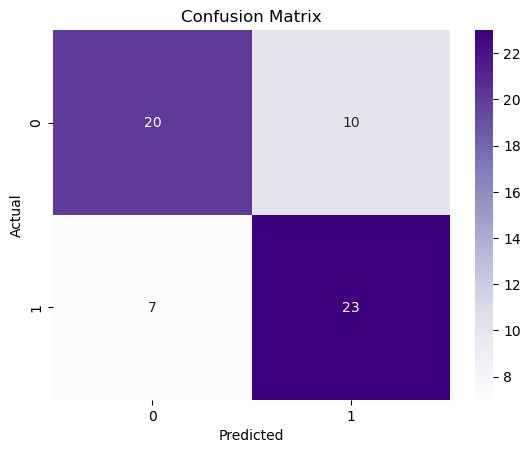

Accuracy: 0.7167


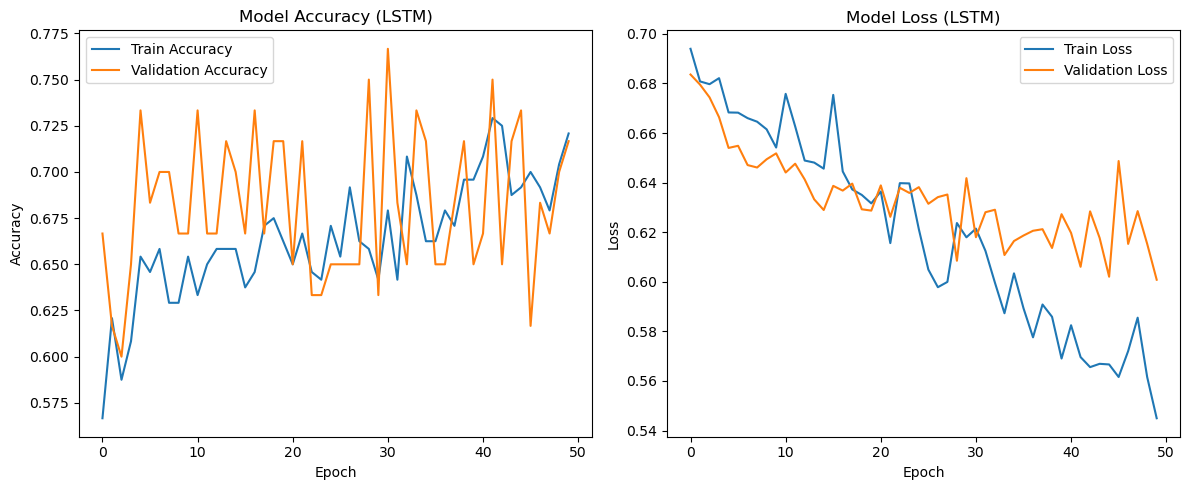

In [291]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X and y are already prepared (pose features)

# Step 1: Reshape X for LSTM
# LSTM expects input in the shape: (samples, timesteps, features)
# If your pose features are just a 1D array now, we expand dims
X = np.expand_dims(X, axis=1)

print("New X shape for LSTM:", X.shape)

# Step 2: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 3: Build LSTM Model
model_lstm = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Sigmoid for binary classification
])

# Step 4: Compile
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 5: Train
history = model_lstm.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

# Step 6: Save Model
model_lstm.save('lstm_fight_detection.h5')
print("✅ Model saved as 'lstm_fight_detection.h5'")

# Step 7: Evaluate
y_pred_prob = model_lstm.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Step 8: Plot Accuracy and Loss
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy (LSTM)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (LSTM)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [293]:
from tensorflow.keras.models import load_model

# Load the saved LSTM model
model_lstm = load_model('lstm_fight_detection.h5')

# Then you can predict
y_pred = model_lstm.predict(X_test)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


In [297]:
model.save('models/lstm_model.keras')


AttributeError: 'RandomForestClassifier' object has no attribute 'save'

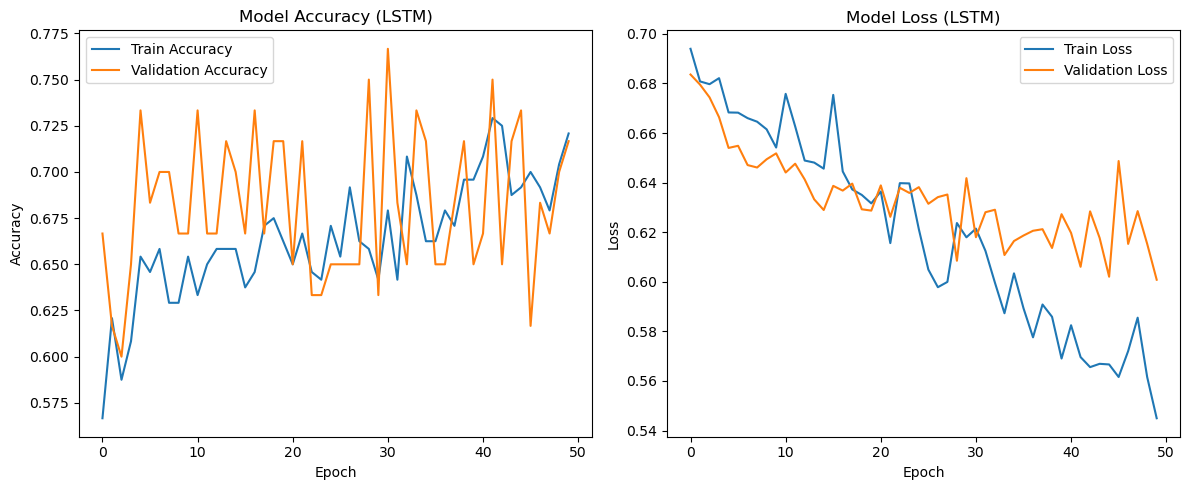

In [299]:
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy (LSTM)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (LSTM)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


# Bi-LSTM Model

In [302]:
print(X.shape)


(300, 1, 264)


In [304]:
X_reshaped = X.transpose(0, 2, 1)  # (300, 264, 1)
print(X_reshaped.shape)


(300, 264, 1)


Epoch 1/30


C:\Users\BALA KARTHIK KOSURI\anaconda3\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 265ms/step - accuracy: 0.4544 - loss: 0.6955 - val_accuracy: 0.5000 - val_loss: 0.6871
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.5599 - loss: 0.6863 - val_accuracy: 0.5833 - val_loss: 0.6831
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.6008 - loss: 0.6821 - val_accuracy: 0.6167 - val_loss: 0.6747
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - accuracy: 0.6297 - loss: 0.6739 - val_accuracy: 0.6333 - val_loss: 0.6567
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.6094 - loss: 0.6673 - val_accuracy: 0.6333 - val_loss: 0.6401
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.6292 - loss: 0.6448 - val_accuracy: 0.6667 - val_loss: 0.6390
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.6285 - loss: 0.6470 - val_accuracy: 0.6833 - val_loss: 0.6393
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.6165 - loss: 0.6508 - val_accuracy: 0.6333 - val_loss: 0.6356
Epo

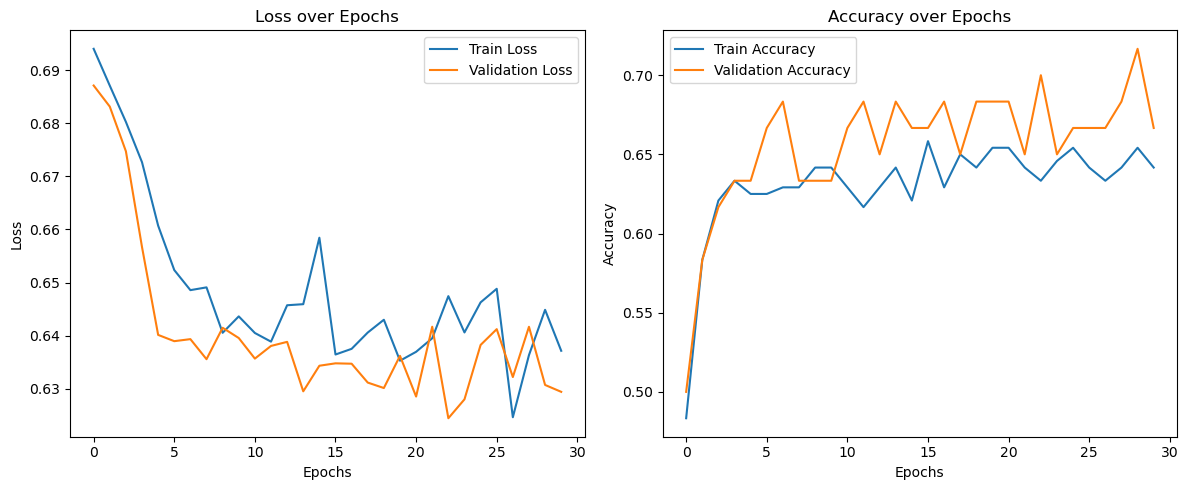

In [306]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Assuming your reshaped data
X_reshaped = X.transpose(0, 2, 1)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, random_state=42, stratify=y)

# Build Bi-LSTM Model
model = Sequential()
model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(X_reshaped.shape[1], X_reshaped.shape[2])))
model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(32)))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))

# Save the model
model.save('bi_lstm_model.h5')

# Plot Loss and Accuracy
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [308]:
model.save('bi_lstm_model.h5')


In [310]:
model.save('models/bi_lstm_model.keras')


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step


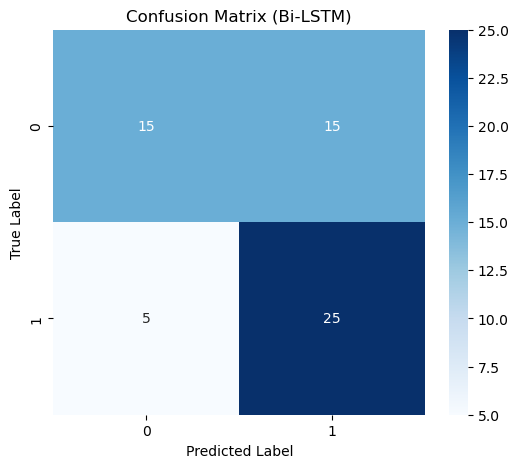


Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.50      0.60        30
           1       0.62      0.83      0.71        30

    accuracy                           0.67        60
   macro avg       0.69      0.67      0.66        60
weighted avg       0.69      0.67      0.66        60



In [312]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predict on Test Data
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to 0 or 1

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Bi-LSTM)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


In [314]:
timesteps = 30      # frames per video
feature_dim = 132   # features per frame


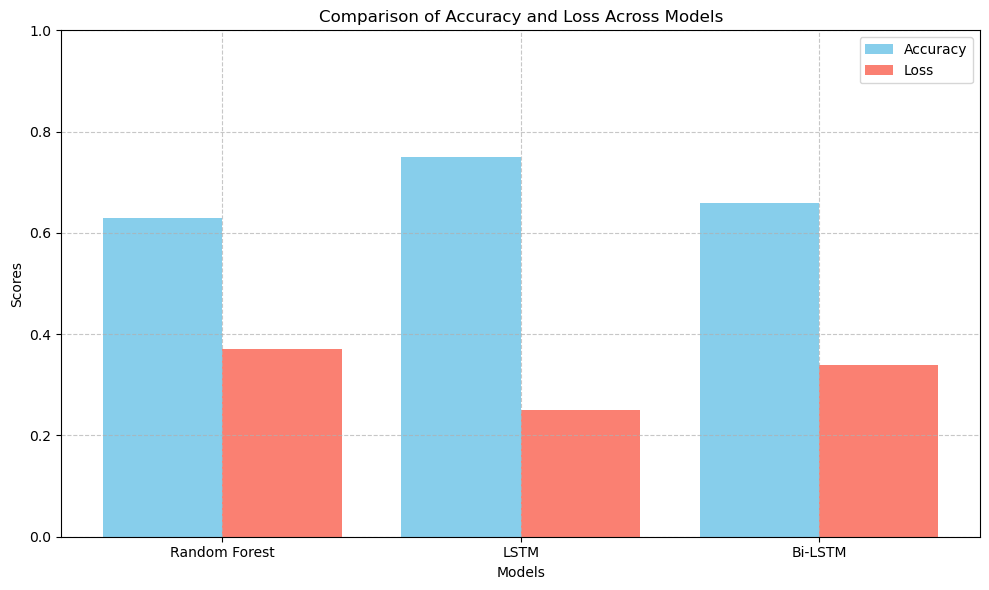

In [316]:
import matplotlib.pyplot as plt

# Model names
models = ['Random Forest', 'LSTM', 'Bi-LSTM']

# Accuracy values (approx)
accuracy = [0.63, 0.75, 0.66]  # You can slightly adjust if needed

# Loss values (approx)
loss = [1 - acc for acc in accuracy]

# Plotting
x = range(len(models))

plt.figure(figsize=(10, 6))

# Accuracy bar
plt.bar([i - 0.2 for i in x], accuracy, width=0.4, label='Accuracy', color='skyblue')

# Loss bar
plt.bar([i + 0.2 for i in x], loss, width=0.4, label='Loss', color='salmon')

# Labels and titles
plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Comparison of Accuracy and Loss Across Models')
plt.xticks(x, models)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()